# Sales Analytics — Exploratory Data Analysis
**Final Project · Data Analysis and Visualization Course**

This notebook covers:
1. Data loading & cleaning
2. Statistical summaries
3. Distribution analysis
4. Correlation analysis
5. Trend analysis
6. Key findings

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

BLUE   = '#1976D2'
ORANGE = '#ff7f0e'
GREEN  = '#2ca02c'

## 1. Data Loading & Cleaning

In [2]:
df_raw = pd.read_csv('data/sales_data.csv')
print(f'Shape (raw): {df_raw.shape}')
df_raw.head()

Shape (raw): (10000, 17)


,order_id,order_date,customer_id,customer_name,segment,region,city,category,sub_category,product_name,quantity,unit_price,discount,sales,profit,shipping_cost,ship_mode
0,ORD-20000,2024-06-14,CUST-00362,Nancy Rodriguez,Corporate,West,Los Angeles,Office Supplies,Binders,Binders - Model Z592,10,15.61,0.4,93.66,27.04,14.48,Standard Class
1,ORD-20001,2023-10-31,CUST-01992,Mark Lee,Consumer,North,Minneapolis,Furniture,Wardrobes,Wardrobes - Model N878,8,577.72,0.4,2773.06,-283.01,37.74,Second Class
2,ORD-20002,2022-03-27,CUST-01954,Donald Garcia,Consumer,West,San Francisco,Furniture,Office Chairs,Office Chairs - Model T650,7,633.35,0.0,4433.45,955.85,55.53,Second Class
3,ORD-20003,2024-01-18,CUST-01489,Betty Thomas,Corporate,North,Detroit,Technology,Keyboards,Keyboards - Model P173,5,88.48,0.3,309.68,6.39,35.04,First Class
4,ORD-20004,2024-09-05,CUST-01465,Jessica Moore,Home Office,East,New York,Furniture,Filing Cabinets,Filing Cabinets - Model X483,4,104.87,NaN,419.48,-19.09,31.54,Same Day


In [3]:
print('Data types:\n', df_raw.dtypes)
print('\nMissing values:\n', df_raw.isnull().sum())
print(f'\nDuplicates: {df_raw.duplicated(subset=["order_id"]).sum()}')

Data types:
 order_id          object
order_date        object
customer_id       object
customer_name     object
segment           object
region            object
city              object
category          object
sub_category      object
product_name      object
quantity           int64
unit_price       float64
discount         float64
sales            float64
profit           float64
shipping_cost    float64
ship_mode         object
dtype: object

Missing values:
 order_id          0
order_date        0
customer_id       0
customer_name     0
segment           0
region            0
city              0
category          0
sub_category      0
product_name      0
quantity          0
unit_price        0
discount         25
sales             0
profit            0
shipping_cost    25
ship_mode         0
dtype: int64

Duplicates: 0


In [4]:
df = df_raw.copy()

# Remove duplicates
df.drop_duplicates(subset=['order_id'], inplace=True)

# Fill missing values
df['discount']      = df['discount'].fillna(df['discount'].median())
df['shipping_cost'] = df['shipping_cost'].fillna(df['shipping_cost'].median())

# Parse dates
df['order_date']  = pd.to_datetime(df['order_date'])
df['year']        = df['order_date'].dt.year
df['month']       = df['order_date'].dt.month
df['month_name']  = df['order_date'].dt.strftime('%b')
df['quarter']     = 'Q' + df['order_date'].dt.quarter.astype(str)
df['year_month']  = df['order_date'].dt.to_period('M').astype(str)
df['day_of_week'] = df['order_date'].dt.strftime('%A')

# Outlier detection — IQR method on sales
q1, q3 = df['sales'].quantile(.25), df['sales'].quantile(.75)
iqr = q3 - q1
df['is_outlier'] = (df['sales'] < q1 - 3*iqr) | (df['sales'] > q3 + 3*iqr)

print(f'Clean shape: {df.shape}')
print(f'Outliers detected: {df["is_outlier"].sum()} rows ({df["is_outlier"].mean()*100:.2f}%)')
print('\nMissing after cleaning:\n', df.isnull().sum())

Clean shape: (10000, 24)
Outliers detected: 319 rows (3.19%)

Missing after cleaning:
 order_id         0
order_date       0
customer_id      0
customer_name    0
segment          0
region           0
city             0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
discount         0
sales            0
profit           0
shipping_cost    0
ship_mode        0
year             0
month            0
month_name       0
quarter          0
year_month       0
day_of_week      0
is_outlier       0
dtype: int64


## 2. Statistical Summaries

In [5]:
print('=== Numerical Summary ===')
df[['quantity','unit_price','discount','sales','profit','shipping_cost']].describe().round(2)

=== Numerical Summary ===


,quantity,unit_price,discount,sales,profit,shipping_cost
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,5.51,349.81,0.14,1644.52,188.43,31.87
std,2.87,438.50,0.13,2505.60,502.33,16.50
min,1.00,2.07,0.00,1.65,-1817.74,3.01
25%,3.00,27.74,0.00,122.47,7.62,17.60
50%,6.00,184.98,0.10,623.33,41.06,31.93
75%,8.00,502.84,0.20,2122.49,192.76,46.34
max,10.00,2494.22,0.40,24170.80,6848.00,59.98


In [6]:
print('=== Categorical Summary ===')
for col in ['category','segment','region','ship_mode']:
    print(f'\n{col}:')
    print(df[col].value_counts())

=== Categorical Summary ===

category:
category
Technology         3369
Furniture          3321
Office Supplies    3310
Name: count, dtype: int64

segment:
segment
Home Office    3398
Consumer       3376
Corporate      3226
Name: count, dtype: int64

region:
region
West       2153
East       2052
Central    1963
North      1923
South      1909
Name: count, dtype: int64

ship_mode:
ship_mode
Same Day          2550
Second Class      2497
First Class       2480
Standard Class    2473
Name: count, dtype: int64


In [7]:
print('=== Key Business Metrics ===')
print(f'Total Sales:    ${df["sales"].sum():>15,.0f}')
print(f'Total Profit:   ${df["profit"].sum():>15,.0f}')
print(f'Profit Margin:  {df["profit"].sum()/df["sales"].sum()*100:>14.1f}%')
print(f'Avg Order Value:${df["sales"].mean():>15,.0f}')
print(f'Unique Customers:{df["customer_id"].nunique():>14,}')
print(f'Total Orders:   {len(df):>16,}')
print(f'Date Range:     {df["order_date"].min().date()} → {df["order_date"].max().date()}')

=== Key Business Metrics ===
Total Sales:    $     16,445,209
Total Profit:   $      1,884,320
Profit Margin:            11.5%
Avg Order Value:$          1,645
Unique Customers:         1,986
Total Orders:             10,000
Date Range:     2022-01-01 → 2024-12-31


## 3. Distribution Analysis

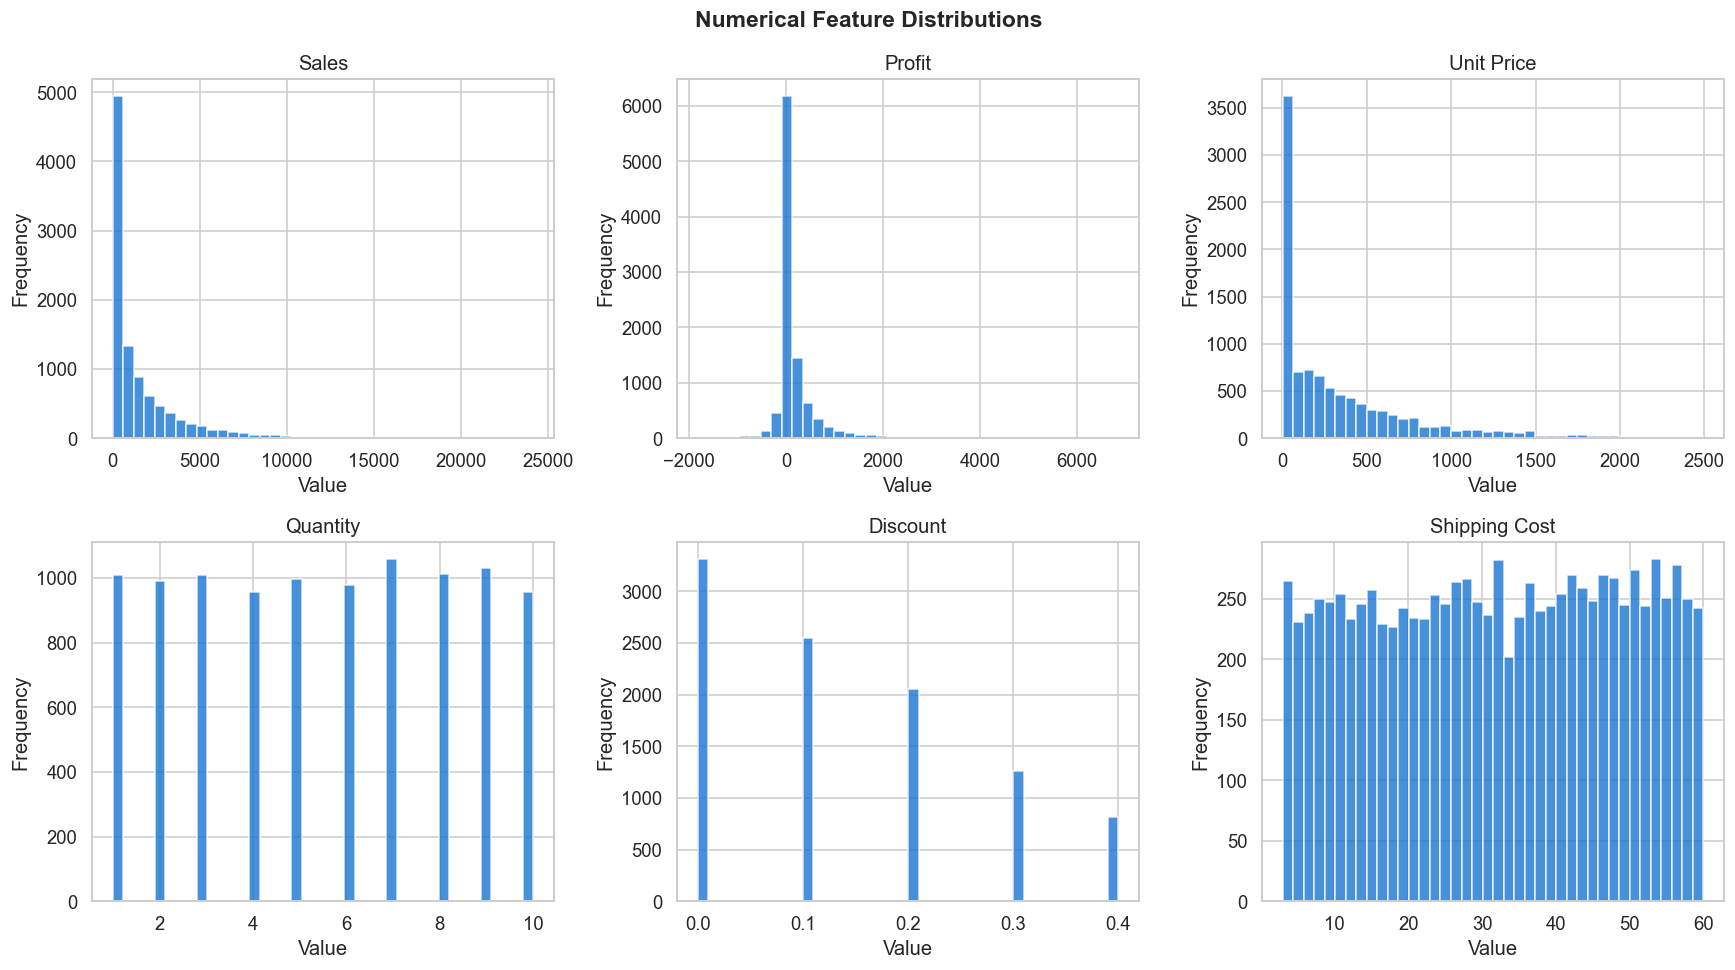

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Numerical Feature Distributions', fontsize=15, fontweight='bold')

cols = ['sales', 'profit', 'unit_price', 'quantity', 'discount', 'shipping_cost']
for ax, col in zip(axes.flat, cols):
    ax.hist(df[col], bins=40, color=BLUE, alpha=.8, edgecolor='white')
    ax.set_title(col.replace('_', ' ').title())
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight')
plt.show()

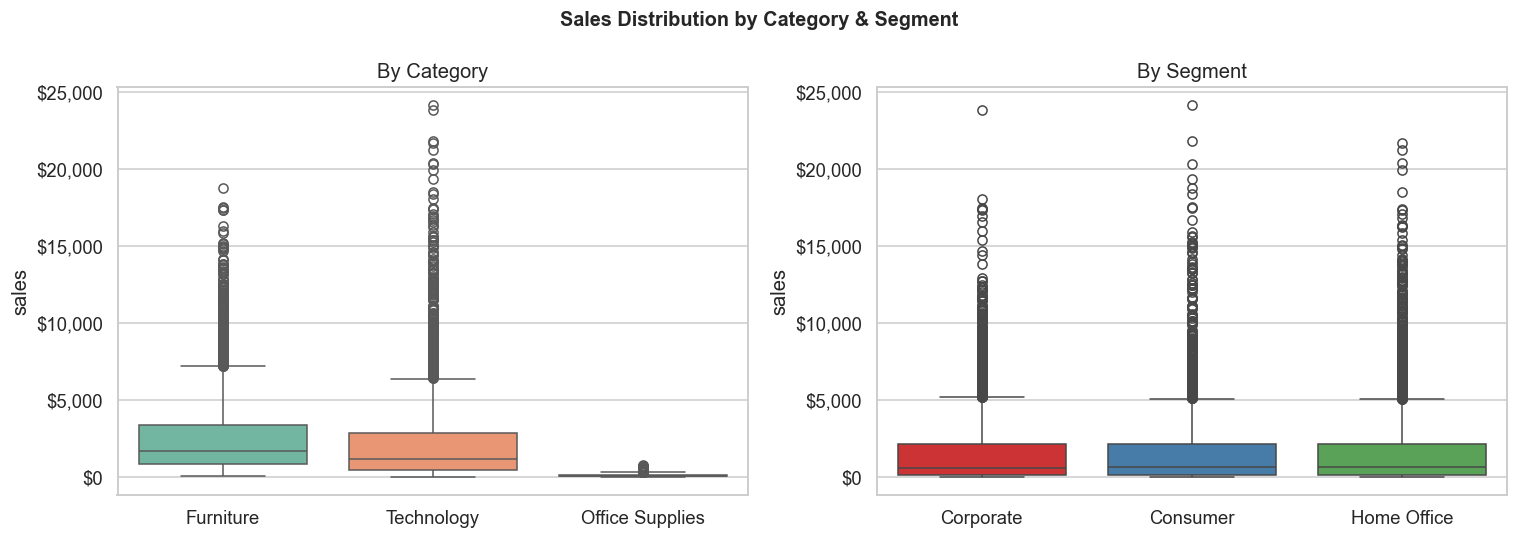

In [9]:
# Sales distribution by category (box plots)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Sales Distribution by Category & Segment', fontsize=13, fontweight='bold')

cat_order = df.groupby('category')['sales'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='category', y='sales', order=cat_order,
            palette='Set2', ax=axes[0])
axes[0].set_title('By Category')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

sns.boxplot(data=df, x='segment', y='sales',
            palette='Set1', ax=axes[1])
axes[1].set_title('By Segment')
axes[1].set_xlabel('')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()

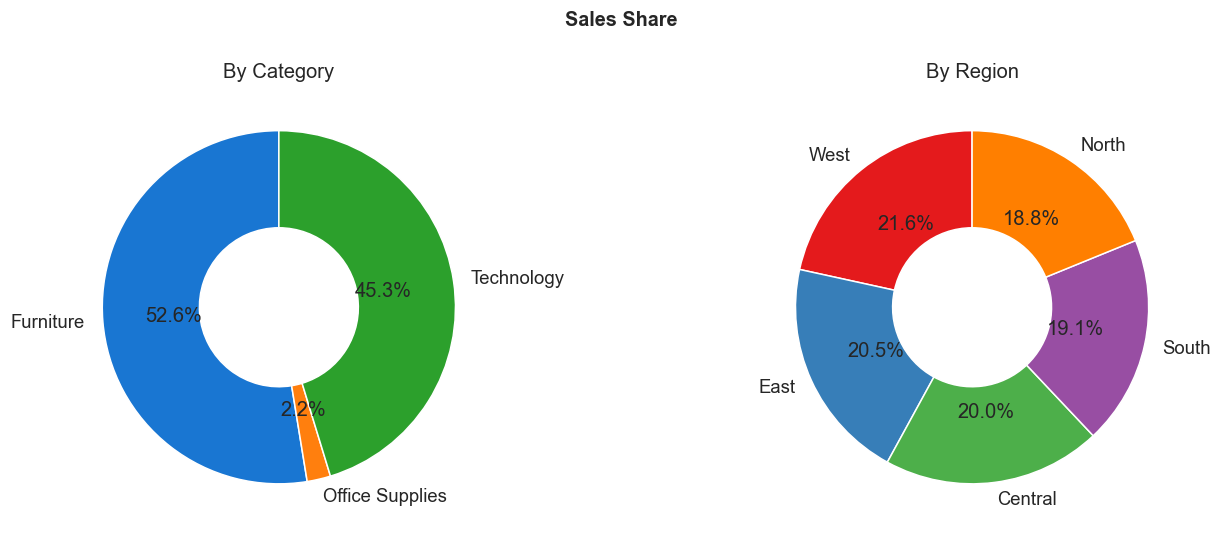

In [10]:
# Category & region pie
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Sales Share', fontsize=13, fontweight='bold')

cat_s = df.groupby('category')['sales'].sum()
axes[0].pie(cat_s, labels=cat_s.index, autopct='%1.1f%%',
            colors=['#1976D2','#ff7f0e','#2ca02c'],
            startangle=90, wedgeprops=dict(width=.55))
axes[0].set_title('By Category')

reg_s = df.groupby('region')['sales'].sum().sort_values(ascending=False)
axes[1].pie(reg_s, labels=reg_s.index, autopct='%1.1f%%',
            colors=sns.color_palette('Set1', len(reg_s)),
            startangle=90, wedgeprops=dict(width=.55))
axes[1].set_title('By Region')

plt.tight_layout()
plt.savefig('eda_pie.png', bbox_inches='tight')
plt.show()

## 4. Correlation Analysis

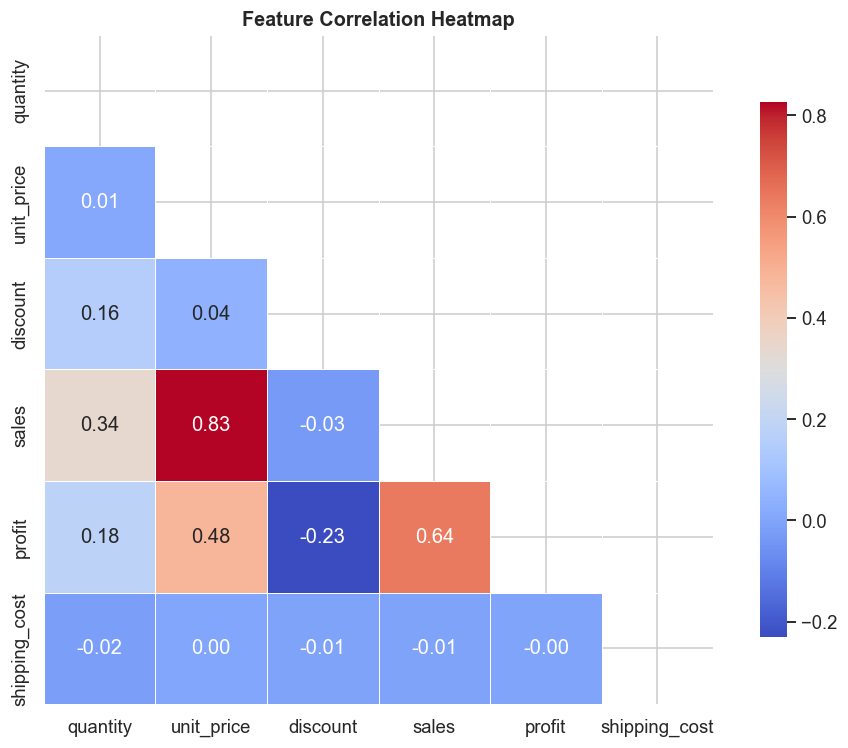


Top correlations with sales:
unit_price       0.827235
profit           0.637186
quantity         0.338345
discount        -0.028444
shipping_cost   -0.005070
Name: sales, dtype: float64


In [11]:
num_cols = ['quantity','unit_price','discount','sales','profit','shipping_cost']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, square=True, linewidths=.5,
            cbar_kws={'shrink': .8})
plt.title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight')
plt.show()

print('\nTop correlations with sales:')
print(corr['sales'].drop('sales').sort_values(key=abs, ascending=False))

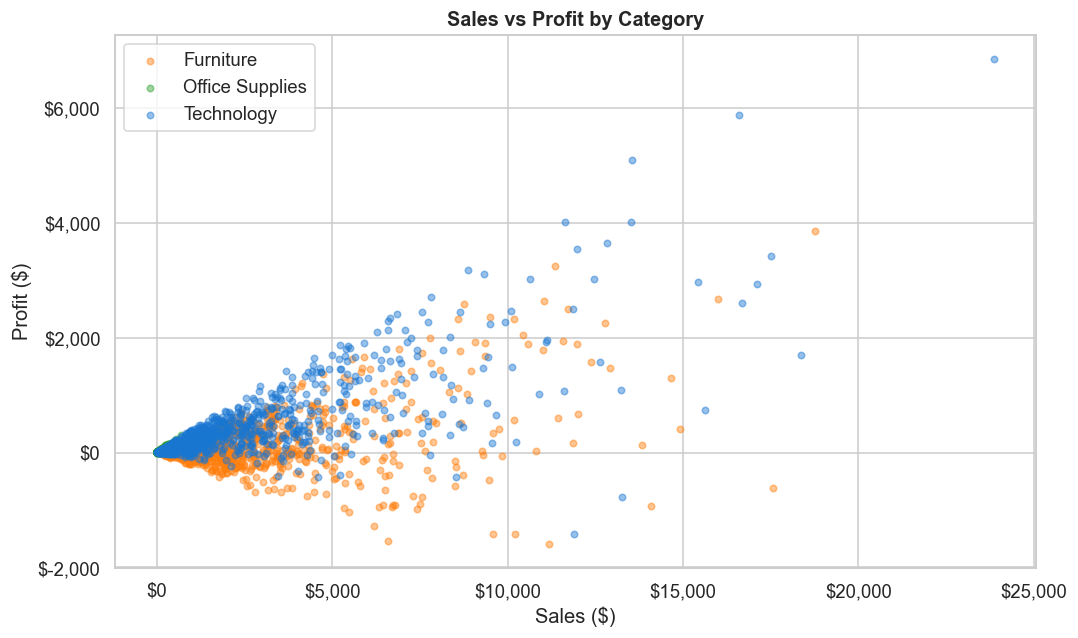

In [12]:
# Scatter: sales vs profit coloured by category
fig, ax = plt.subplots(figsize=(10, 6))
colors = {'Technology':'#1976D2','Furniture':'#ff7f0e','Office Supplies':'#2ca02c'}
for cat, grp in df.sample(3000, random_state=42).groupby('category'):
    ax.scatter(grp['sales'], grp['profit'], alpha=.45, s=18,
               color=colors[cat], label=cat)
ax.set_xlabel('Sales ($)')
ax.set_ylabel('Profit ($)')
ax.set_title('Sales vs Profit by Category', fontsize=13, fontweight='bold')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('eda_scatter.png', bbox_inches='tight')
plt.show()

## 5. Trend Analysis

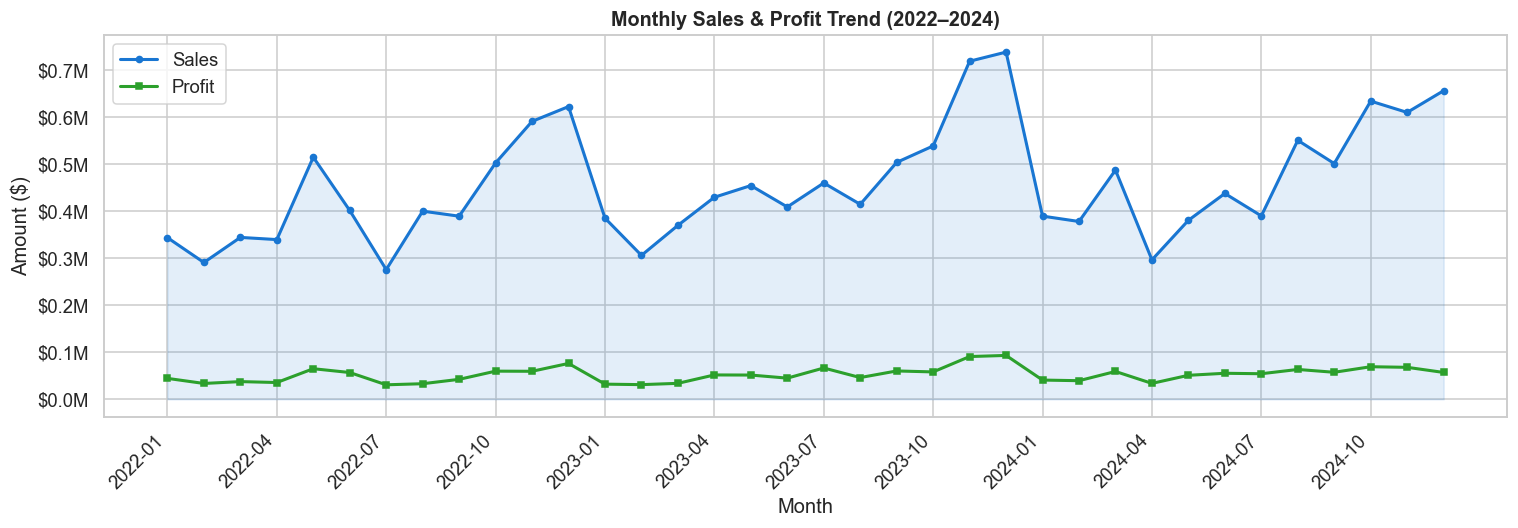

In [13]:
# Monthly sales trend
monthly = df.groupby('year_month').agg(
    sales=('sales','sum'), profit=('profit','sum')
).reset_index().sort_values('year_month')

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['year_month'], monthly['sales'], color=BLUE,
        linewidth=2, marker='o', markersize=4, label='Sales')
ax.fill_between(monthly['year_month'], monthly['sales'],
                alpha=.12, color=BLUE)
ax.plot(monthly['year_month'], monthly['profit'], color=GREEN,
        linewidth=2, marker='s', markersize=4, label='Profit')
ax.set_title('Monthly Sales & Profit Trend (2022–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
ax.legend()
step = max(1, len(monthly)//12)
ax.set_xticks(range(0, len(monthly), step))
ax.set_xticklabels(monthly['year_month'].iloc[::step], rotation=45, ha='right')
plt.tight_layout()
plt.savefig('eda_trend.png', bbox_inches='tight')
plt.show()

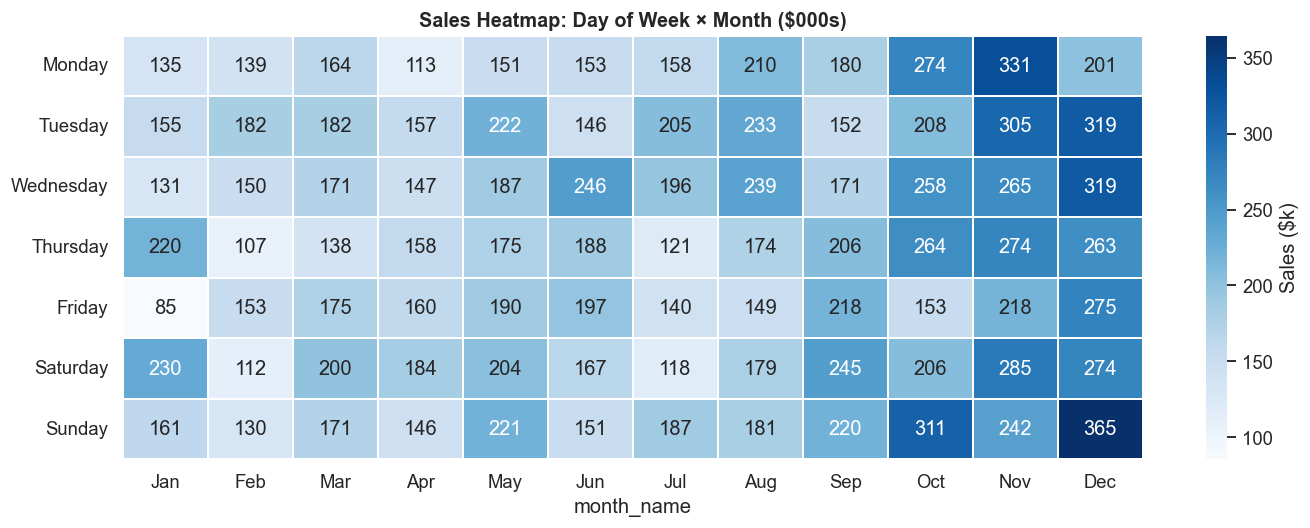

In [14]:
# Heatmap: day of week × month
day_order   = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

pivot = df.pivot_table(values='sales', index='day_of_week',
                       columns='month_name', aggfunc='sum', fill_value=0)
pivot = pivot.reindex([d for d in day_order   if d in pivot.index])
pivot = pivot.reindex(columns=[m for m in month_order if m in pivot.columns])

plt.figure(figsize=(13, 5))
sns.heatmap(pivot / 1e3, annot=True, fmt='.0f', cmap='Blues',
            linewidths=.3, cbar_kws={'label': 'Sales ($k)'})
plt.title('Sales Heatmap: Day of Week × Month ($000s)',
          fontsize=13, fontweight='bold')
plt.ylabel('')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()

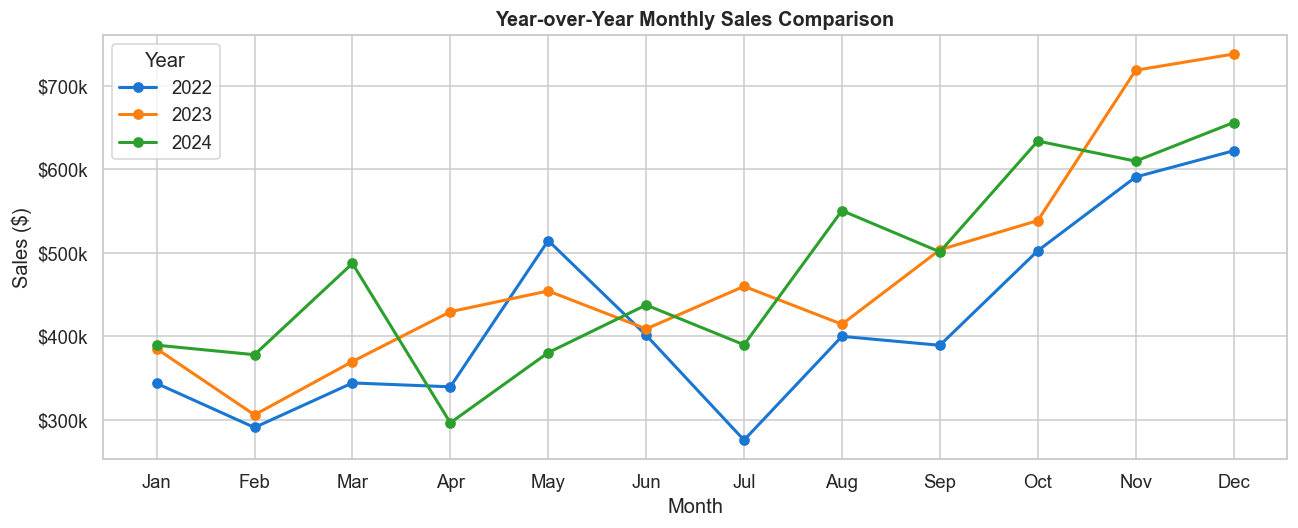

In [15]:
# YoY monthly comparison
yoy = df.groupby(['year','month'])['sales'].sum().reset_index()
month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(12, 5))
colors_yoy = {'2022': '#1976D2', '2023': '#ff7f0e', '2024': '#2ca02c'}
for yr, grp in yoy.groupby('year'):
    ax.plot(grp['month'], grp['sales'], marker='o', linewidth=2,
            label=str(yr), color=colors_yoy[str(yr)])
ax.set_title('Year-over-Year Monthly Sales Comparison',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Sales ($)')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e3:.0f}k'))
ax.legend(title='Year')
plt.tight_layout()
plt.savefig('eda_yoy.png', bbox_inches='tight')
plt.show()

## 6. Key Findings

In [16]:
print('='*60)
print('KEY FINDINGS')
print('='*60)

# Top products
top3 = df.groupby('sub_category')['sales'].sum().sort_values(ascending=False).head(3)
print('\n1. TOP REVENUE SUB-CATEGORIES:')
for p, v in top3.items():
    print(f'   • {p}: ${v:,.0f}')

# Peak month
mo = df.groupby('month_name')['sales'].sum()
mo = mo.reindex([m for m in month_labels if m in mo.index])
print(f'\n2. SEASONALITY:')
print(f'   • Peak month:   {mo.idxmax()} (${mo.max():,.0f})')
print(f'   • Lowest month: {mo.idxmin()} (${mo.min():,.0f})')

# Regions
reg = df.groupby('region').agg(sales=('sales','sum'), profit=('profit','sum'))
reg['margin'] = reg['profit'] / reg['sales'] * 100
print(f'\n3. REGIONS:')
print(f'   • Best sales:   {reg["sales"].idxmax()} (${reg["sales"].max():,.0f})')
print(f'   • Best margin:  {reg["margin"].idxmax()} ({reg["margin"].max():.1f}%)')
print(f'   • Worst margin: {reg["margin"].idxmin()} ({reg["margin"].min():.1f}%)')

# Customers
repeat = (df.groupby('customer_id')['order_id'].count() > 1).mean() * 100
top_seg = df.groupby('segment')['sales'].sum().idxmax()
print(f'\n4. CUSTOMERS:')
print(f'   • Repeat rate: {repeat:.1f}%')
print(f'   • Top segment: {top_seg}')

# Discount analysis
disc_groups = df.groupby(pd.cut(df['discount'], bins=[-0.01,0,0.1,0.2,0.3,0.5]))['profit'].mean()
print(f'\n5. DISCOUNT IMPACT (avg profit):')
for rng, val in disc_groups.items():
    print(f'   • {rng}: ${val:,.0f}')

# Category margins
cat_m = df.groupby('category').apply(lambda x: x['profit'].sum()/x['sales'].sum()*100)
print(f'\n6. CATEGORY MARGINS:')
for c, m in cat_m.sort_values(ascending=False).items():
    print(f'   • {c}: {m:.1f}%')

KEY FINDINGS

1. TOP REVENUE SUB-CATEGORIES:
   • Laptops: $2,343,859
   • Sofas: $2,327,394
   • Standing Desks: $1,742,494

2. SEASONALITY:
   • Peak month:   Dec ($2,015,553)
   • Lowest month: Feb ($974,304)

3. REGIONS:
   • Best sales:   West ($3,546,523)
   • Best margin:  West (12.0%)
   • Worst margin: East (11.0%)

4. CUSTOMERS:
   • Repeat rate: 96.6%
   • Top segment: Home Office

5. DISCOUNT IMPACT (avg profit):
   • (-0.01, 0.0]: $310
   • (0.0, 0.1]: $228
   • (0.1, 0.2]: $132
   • (0.2, 0.3]: $28
   • (0.3, 0.5]: $-41

6. CATEGORY MARGINS:
   • Office Supplies: 26.8%
   • Technology: 17.9%
   • Furniture: 5.3%
